In [12]:
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8')

# Carregar os dados do arquivo CSV
data = pd.read_csv('../../datasets/classification_results_trial_0001.csv')

data

,image_path,real_class,predicted_class,prob_benign,prob_malign
0,image_001.jpg,malign,malign,0.031429,0.968571
1,image_002.jpg,benign,benign,0.636410,0.363590
2,image_003.jpg,malign,malign,0.314356,0.685644
3,image_004.jpg,benign,benign,0.508571,0.491429
4,image_005.jpg,benign,benign,0.907566,0.092434
...,...,...,...,...,...
95,image_096.jpg,malign,malign,0.349210,0.650790
96,image_097.jpg,benign,benign,0.725956,0.274044
97,image_098.jpg,benign,benign,0.897110,0.102890
98,image_099.jpg,benign,benign,0.887086,0.112914


Faça os gráficos: <br/>
Gráfico de barras: contagem por real_class.

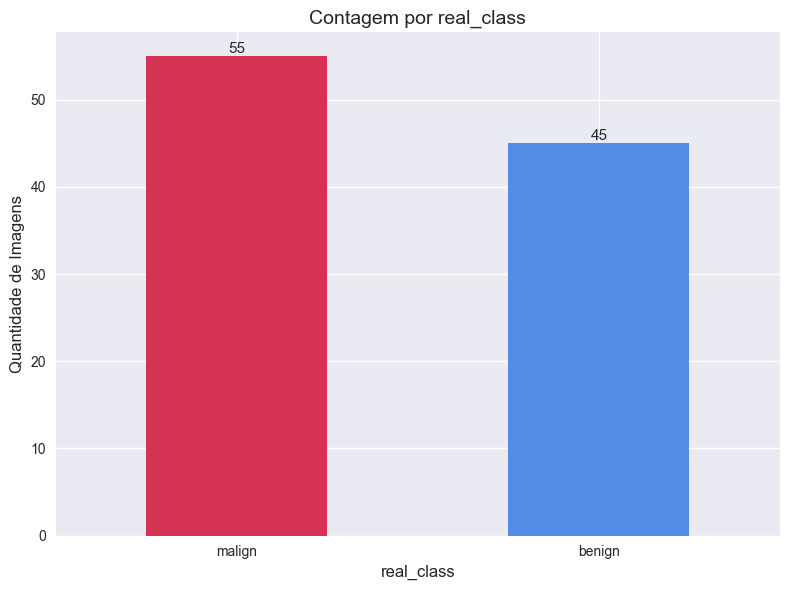

In [17]:
counts = data['real_class'].value_counts()

# Criando o gráfico
fig, ax = plt.subplots(figsize=(8, 6))
counts.plot(kind='bar', ax=ax, color=['#d43353', '#548ce8'])

# Estilização
ax.set_title('Contagem por real_class', fontsize=14)
ax.set_xlabel('real_class', fontsize=12)
ax.set_ylabel('Quantidade de Imagens', fontsize=12)
plt.xticks(rotation=0)

for i, v in enumerate(counts):
    ax.text(i, v + 0.05, str(v), ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

Gráfico de barras: contagem por predicted_class.

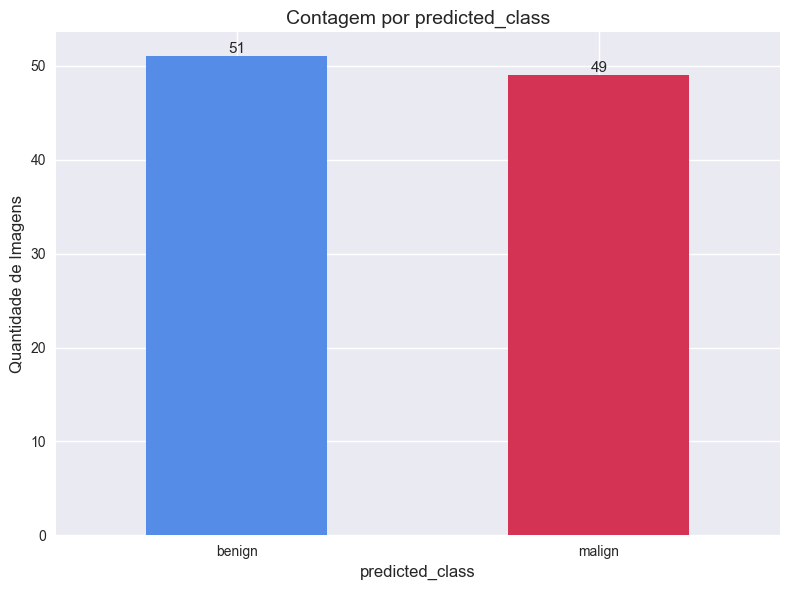

In [18]:
counts = data['predicted_class'].value_counts()

# Criando o gráfico
fig, ax = plt.subplots(figsize=(8, 6))
counts.plot(kind='bar', ax=ax, color=['#548ce8', '#d43353'])

# Estilização
ax.set_title('Contagem por predicted_class', fontsize=14)
ax.set_xlabel('predicted_class', fontsize=12)
ax.set_ylabel('Quantidade de Imagens', fontsize=12)
plt.xticks(rotation=0)

for i, v in enumerate(counts):
    ax.text(i, v + 0.05, str(v), ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

Histograma de prob_benign

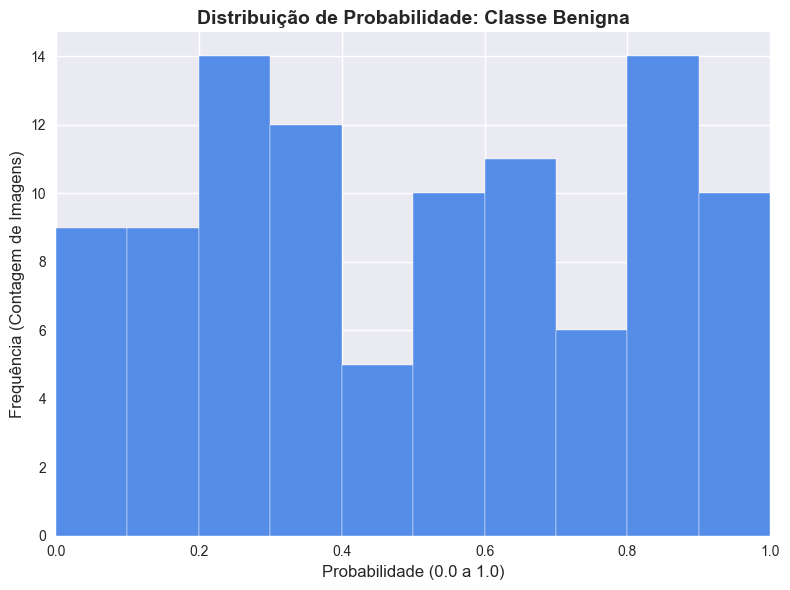

In [22]:
plt.figure(figsize=(8, 6))

# Criando o histograma
# bins=10 divide o intervalo 0-1 em 10 partes
# color define a cor das barras e edgecolor cria a linha de separação entre elas
plt.hist(data['prob_benign'], bins=10, range=(0, 1), color='#548ce8', edgecolor='white')

# Customização do gráfico
plt.title('Distribuição de Probabilidade: Classe Benigna', fontsize=14, fontweight='bold')
plt.xlabel('Probabilidade (0.0 a 1.0)', fontsize=12)
plt.ylabel('Frequência (Contagem de Imagens)', fontsize=12)

plt.xlim(0, 1)

plt.tight_layout()
plt.show()

Histograma de prob_malign.

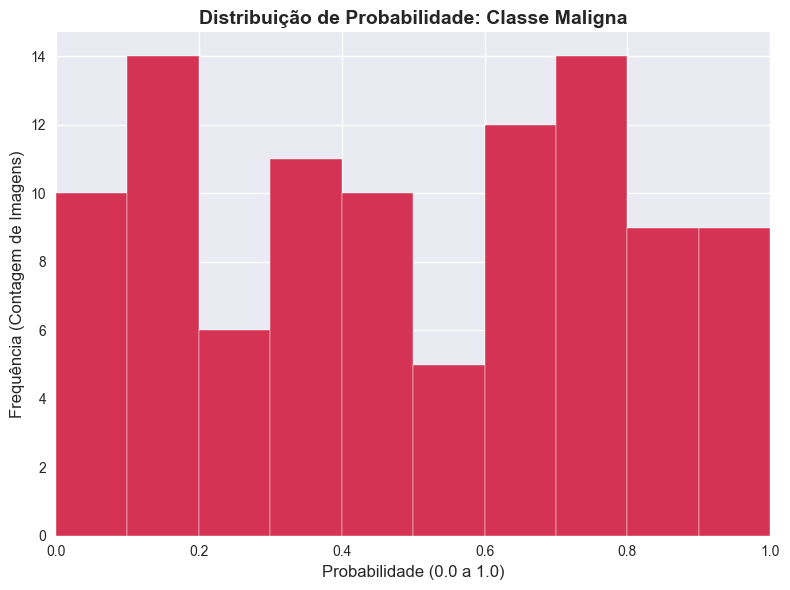

In [24]:
plt.figure(figsize=(8, 6))

plt.hist(data['prob_malign'], bins=10, range=(0, 1), color='#d43353', edgecolor='white')

plt.title('Distribuição de Probabilidade: Classe Maligna', fontsize=14, fontweight='bold')
plt.xlabel('Probabilidade (0.0 a 1.0)', fontsize=12)
plt.ylabel('Frequência (Contagem de Imagens)', fontsize=12)

plt.xlim(0, 1)

plt.tight_layout()
plt.show()

Scatter plot: X=prob_benign, Y=prob_malign, com cor diferente para acerto
vs erro.

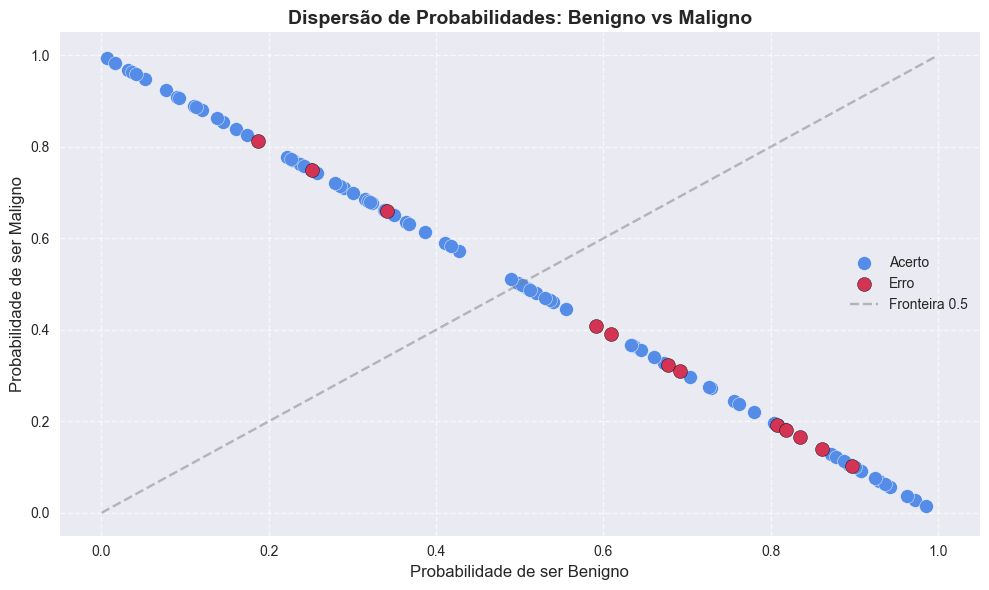

In [30]:
data['status'] = data['real_class'] == data['predicted_class']

plt.figure(figsize=(10, 6))

acertos = data[data['status'] == True]
plt.scatter(acertos['prob_benign'], acertos['prob_malign'], 
            color='#548ce8', s=100, label='Acerto', alpha=1.0, edgecolors='white')

erros = data[data['status'] == False]
if not erros.empty:
    plt.scatter(erros['prob_benign'], erros['prob_malign'], 
                color='#d43353', s=100, label='Erro', alpha=1.0, edgecolors='black')

# Adicionando a linha de decisão (onde as probabilidades se cruzam em 0.5)
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', alpha=0.5, label='Fronteira 0.5')

# Customização 
plt.title('Dispersão de Probabilidades: Benigno vs Maligno', fontsize=14, fontweight='bold')
plt.xlabel('Probabilidade de ser Benigno', fontsize=12)
plt.ylabel('Probabilidade de ser Maligno', fontsize=12)
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Qual erro é mais comum (FP ou FN)? Crie um gráfico que ajude a visualizar isso.

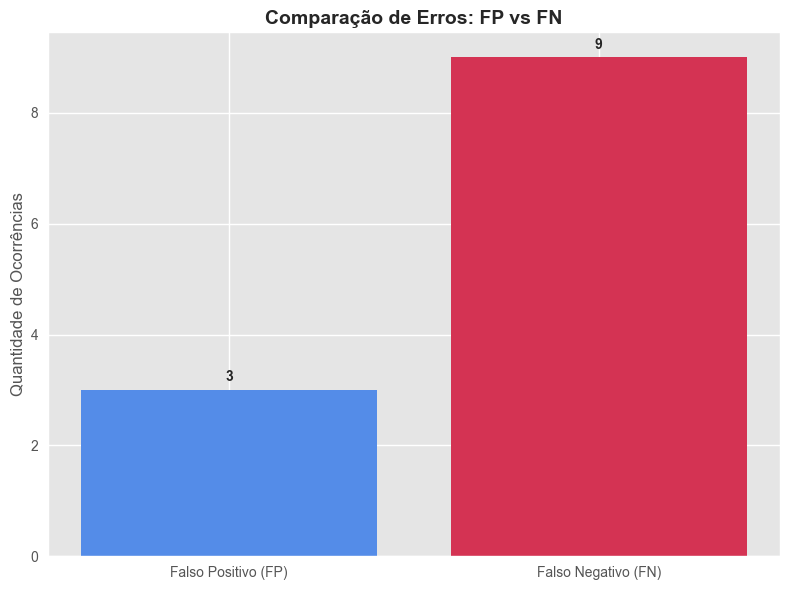

In [34]:
fp = len(data[(data['real_class'] == 'benign') & (data['predicted_class'] == 'malign')])
fn = len(data[(data['real_class'] == 'malign') & (data['predicted_class'] == 'benign')])

# Estilo ggplot
plt.style.use('ggplot')

# Criando o gráfico
labels = ['Falso Positivo (FP)', 'Falso Negativo (FN)']
values = [fp, fn]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(labels, values, color=['#548ce8', '#d43353'])

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.1, int(yval), ha='center', va='bottom', fontweight='bold')

plt.title('Comparação de Erros: FP vs FN', fontsize=14, fontweight='bold')
plt.ylabel('Quantidade de Ocorrências', fontsize=12)
plt.tight_layout()
plt.show()

E em contexto médico: qual é mais preocupante e por quê?

O falso negativo é mais preocupante por causa do seu impacto no atraso do diagnóstico e tratamento do paciente. 